<a href="https://colab.research.google.com/github/minjxxyu0/ESAA/blob/main/ESAA_YB_WEEK_2_2_STUDY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

시본 (Seaborn)

In [1]:
from google.colab import drive
import pandas as pd

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
titanic_df = pd.read_csv('/content/drive/MyDrive/datasets/titanic_train.csv')

In [4]:
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**히스토그램**

* hisplot() 또는 displot() 함수 사용 권장
* hisplot() : Axes 레벨 함수
* displot(): Figure 레벨 함수

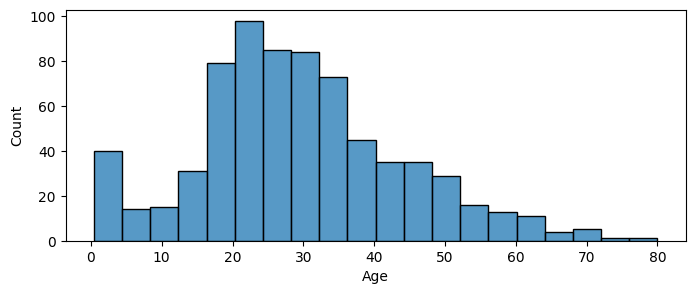

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시본에서도 plt.figure()의 figsize 인자를 입력하여 전체 Figure의 크기 조절
plt.figure(figsize=(8, 3))

# DataFrame의 칼럼명을 자동으로 인식해서 xlabel 값을 할당, ylabel 값은 Count 로 설정
sns.histplot(titanic_df['Age'], bins = 20)
plt.show()

kde = True: 연속 확률분포까지 그려짐

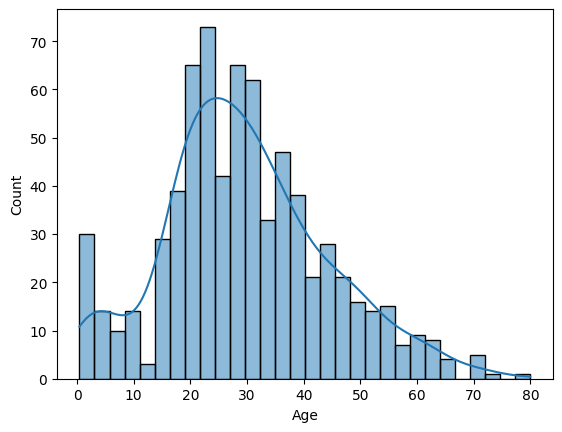

In [7]:
sns.histplot(x='Age', data = titanic_df, bins = 30, kde = True)
plt.show()

<Figure size 800x400 with 0 Axes>

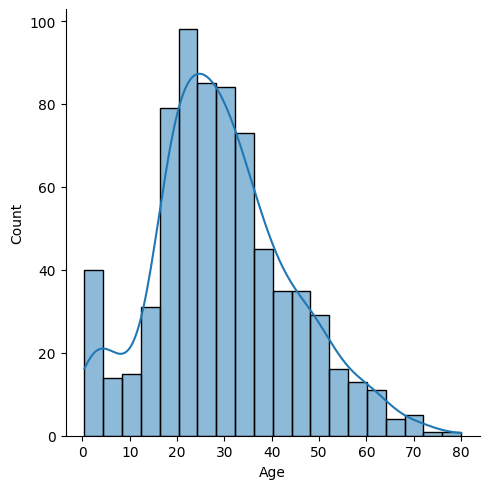

In [8]:
# seaborn의 figure레벨 그래프는 plt.figure()로 Figure 크기를 조절할 수 없습니다
plt.figure(figsize = (8, 4))
sns.displot(x='Age', data = titanic_df, kde = True)
plt.show()

displot 을 이용해서 Figure 크기 조정

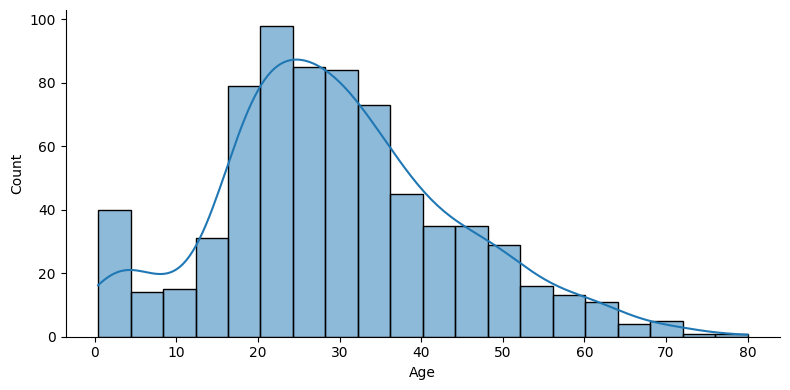

In [11]:
sns.displot(titanic_df['Age'], kde = True, height = 4, aspect=2)
plt.show()

시본의 Figure레벨 함수들은 그래프의 세부적인 변경을 유연성 있게 적용하기가 어려움

**카운트 플롯**
* 이산형 값의 건수를 막대 그래프 형태로 시각화 함
* 주로 카테고리성 칼럼 값별 건수를 시각화하는데 사용됨
* countplot() 사용

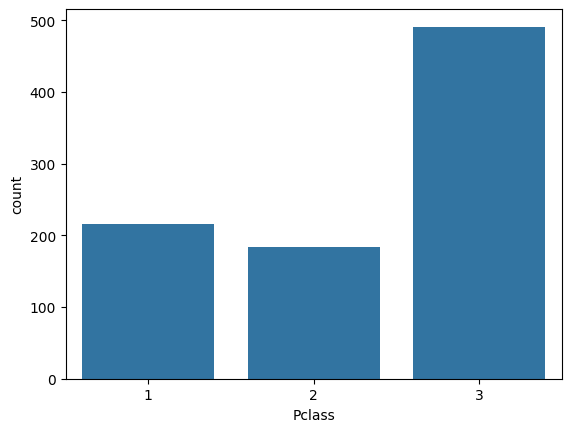

In [12]:
sns.countplot(x='Pclass', data = titanic_df)
plt.show()

**바 플롯(barplot)**
* X축 값이 이산형 값으로 값의 종류가 너무 많지 않을 때 유용하게 사용됨
* 보통 Y축 값은 Y축에 해당하는 칼럼 값의 평균이나 총합으로 표현되는 연속형 값을 가지게됨

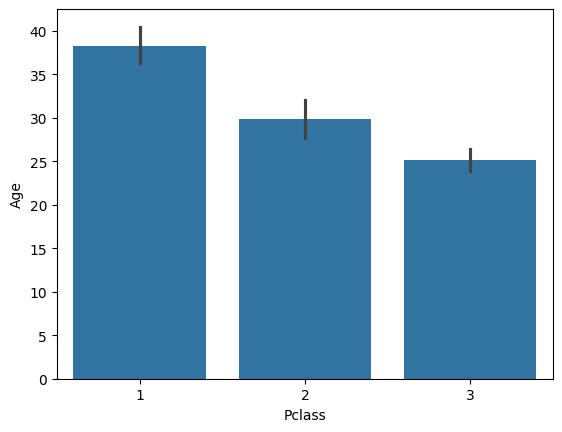

In [13]:
# 자동으로 xlabel, ylabel을 barplot() 의 x 인자값인 Pclass, y인자값이 Age로 설정
sns.barplot(x = 'Pclass', y = 'Age', data = titanic_df)
plt.show()

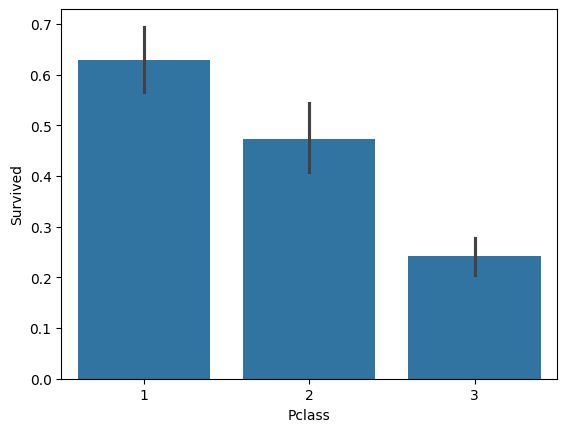

In [15]:
sns.barplot(x='Pclass', y='Survived', data = titanic_df)
plt.show()

barplot() 함수를 사용할 때 Y축 값은 문자열 값으로 입력하고, X축값을 숫자형으로 입력하면 자동으로 수평 막대그래프로 시각화해줌

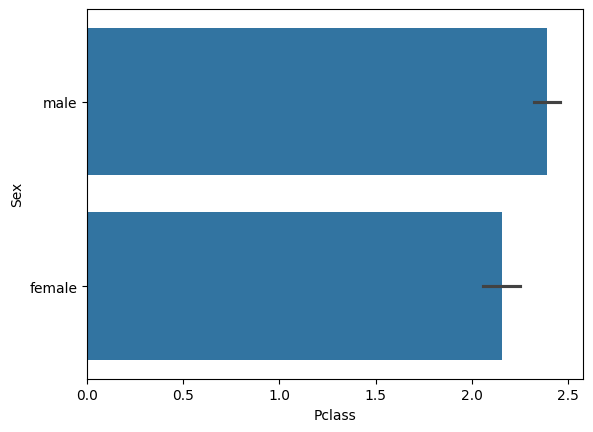

In [16]:
sns.barplot(x='Pclass', y = 'Sex', data=titanic_df)
plt.show()

위 예제와 같이 X축, Y축 모두 이산값을 입력한다면 바 플롯으로 표현되는 정보를 시각적으로 잘못 이해될 수가 있습니다.
* 수직 막대 그래프: Y축 값을 연속형 값으로
* 수평 막대 그래프: X축 값을 연속형 값으로

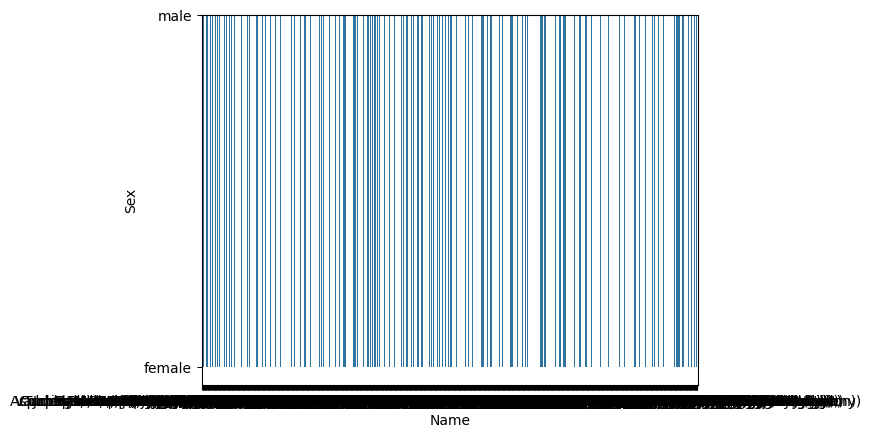

In [17]:
# X인자로 문자열인 Namedmf, y인자로 문자열인 Sex를 입력하므로 barplot은 오류를 발생
sns.barplot(x='Name', y='Sex', data = titanic_df)
plt.show()

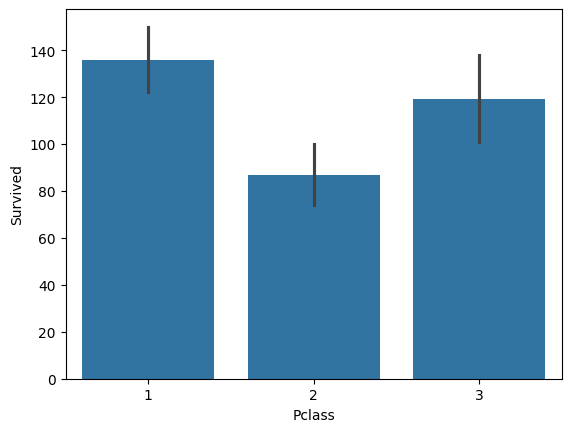

In [18]:
# estimator=sum을 적용하여 평균이 아닌 총합으로 표현
sns.barplot(x='Pclass', y='Survived', data=titanic_df, estimator=sum)
plt.show()

**barplot() 함수의 hue 인자를 사용하여 시각화 정보를 추가적으로 세분화하기**

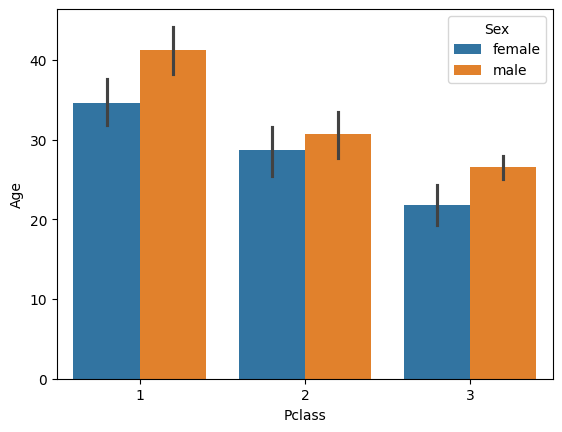

In [19]:
# 아래는 Pclass가 X축값이며 hue파라미터로 Sex를 설정
# 개별 Pclass 값별로 Sex에 따른 Age 평균 값을 구함
sns.barplot(x='Pclass', y = 'Age', hue = 'Sex', data = titanic_df)
plt.show()

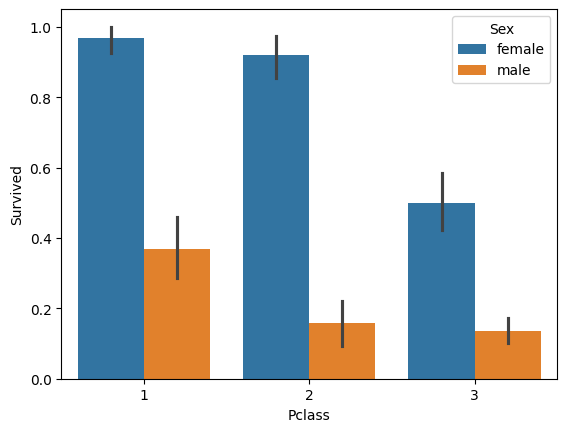

In [20]:
# 개별 Pclass 값별로 Sex에 따른 Survived 평균값을 구함
# Pclass가 X축 값이며 Survived가 Y축 값, hue 파라미터로 Sex를 설정
sns.barplot(x = 'Pclass', y='Survived', hue = 'Sex', data = titanic_df)
plt.show()

**박스 플롯**
* boxplot() 함수 제공
* 분위수(연속형 값에 적용해야 의미 있는 정보) 기반

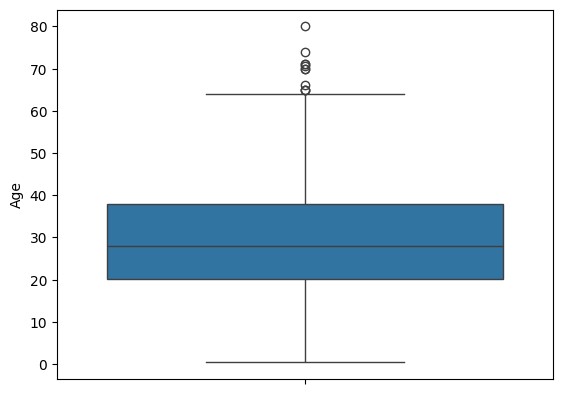

In [21]:
sns.boxplot(y = 'Age', data=titanic_df)
plt.show()

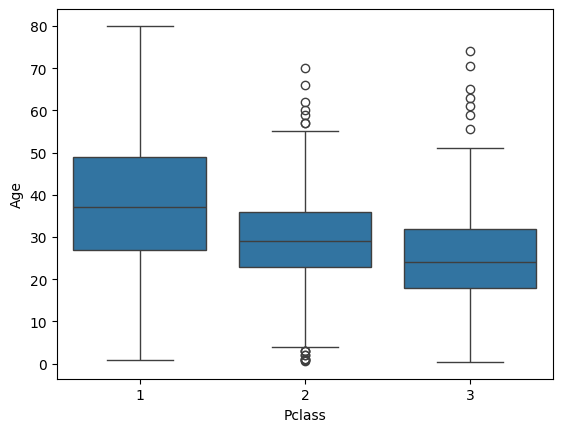

In [22]:
sns.boxplot(x='Pclass', y ='Age', data = titanic_df)
plt.show()

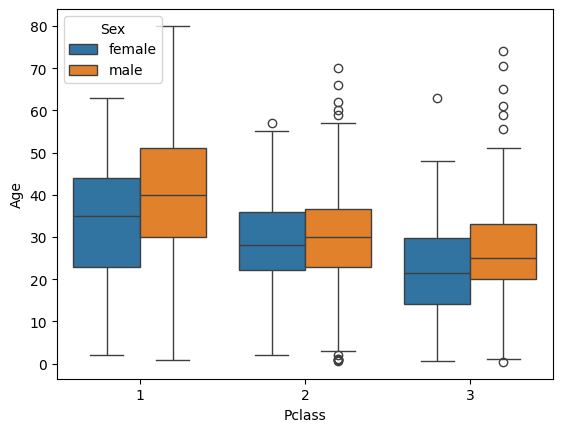

In [23]:
sns.boxplot(x='Pclass', y='Age', hue='Sex', data = titanic_df)
plt.show()

**바이올린 플롯**
* 히스토그램의 연속 확률 분포 곡선과 박스 플롯을 함께 시각화할 수 있음
* 연속형의 값에 적용해야 의미 있는 정보로 시각화될 수 있음
* violinplot() 함수 제공

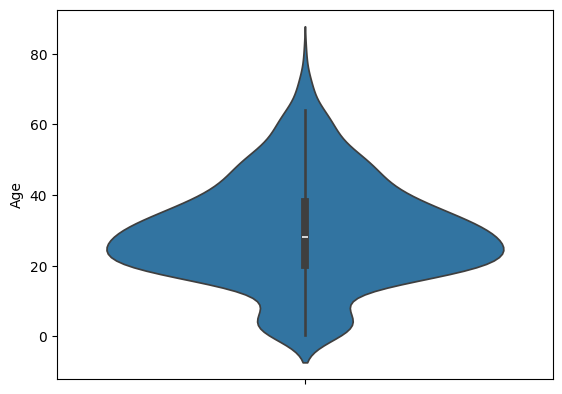

In [25]:
# Age칼럼에 대한 수직 바이올린 플롯 시각화
sns.violinplot(y = 'Age', data = titanic_df)
plt.show()

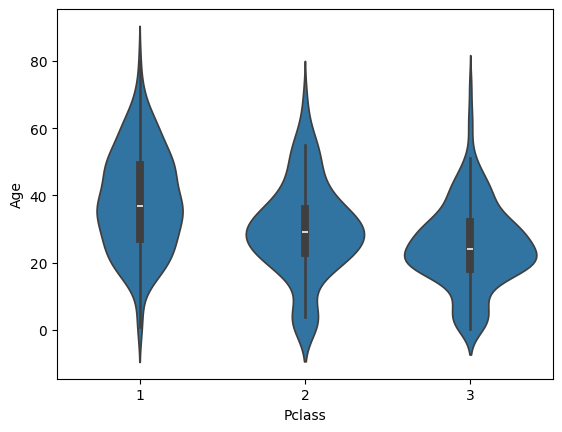

In [26]:
# x축값인 Pclass의 값별로 y축 값인 Age의 바이올린 플롯을 그림
# pClass 값별 Age 데이터 분포를 비교하여 볼 수 있음
sns.violinplot(x='Pclass', y='Age', data = titanic_df)
plt.show()

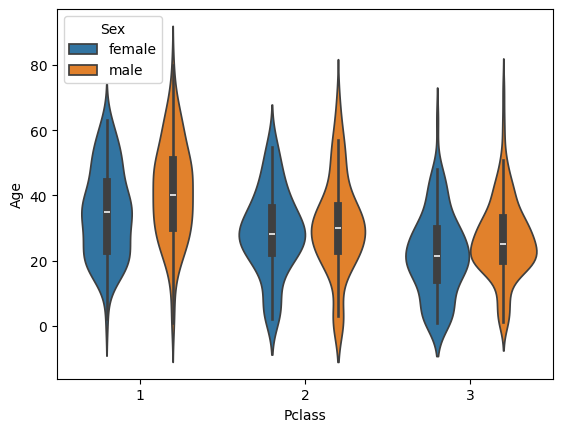

In [27]:
# X축값인 개별 Pclass 내에서 Sex값별로 y축 값인 Age의 바이올린 플롯을 그림
sns.violinplot(x='Pclass', y='Age', hue='Sex', data = titanic_df)
plt.show()

**subplots을 이용하요 시본의 다양한 그래프를 시각화**

index: 0
index: 1
index: 2


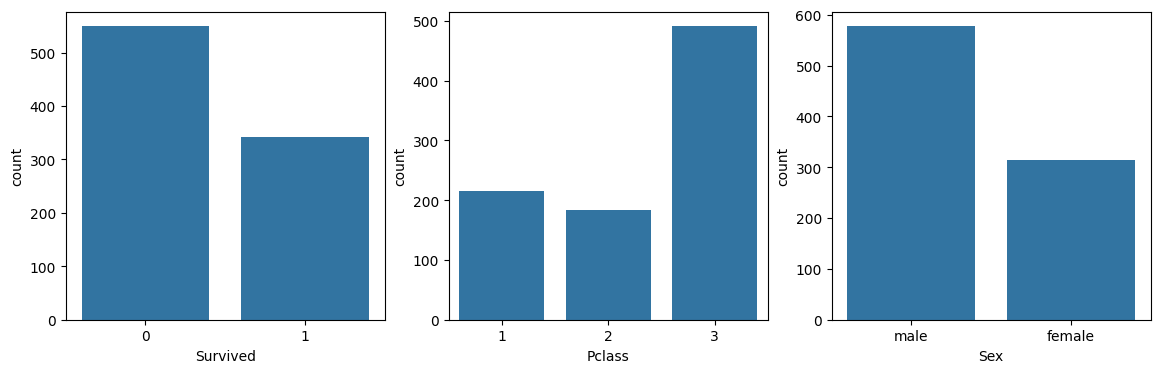

In [30]:
cat_columns = ['Survived', 'Pclass', 'Sex']

# nrows는 1이고, ncols는 칼럼의 개수만큼인 subplots 설정
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14, 4))

for index, column in enumerate(cat_columns):
  print('index:', index)
  # seaborn의 Axes 레벨 function들은 ax인자로 subplots의 어느 Axes에 위치할지 설정
  sns.countplot(x=column, data = titanic_df, ax=axs[index])

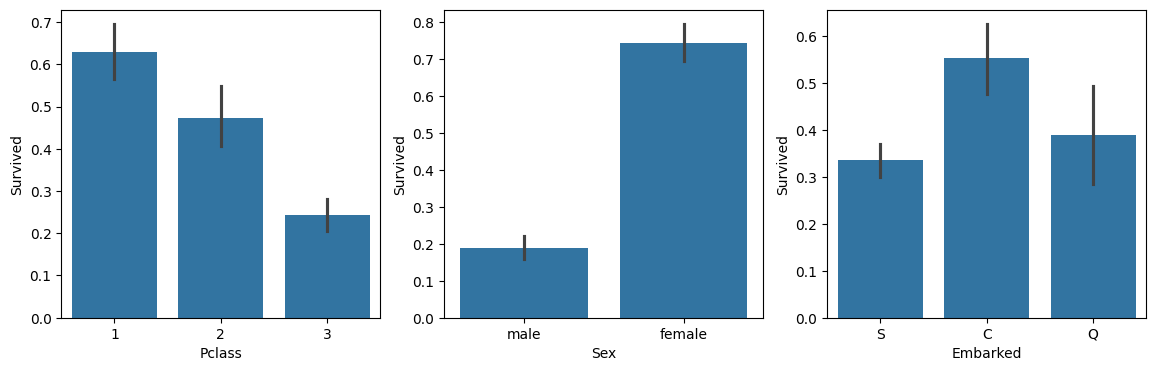

In [31]:
cat_columns = ['Pclass', 'Sex', 'Embarked']

# nrows는 1이고 ncols는 칼럼의 개수만큼 subplots 설정
fig, axs = plt.subplots(nrows=1, ncols = len(cat_columns), figsize=(14, 4))

for index, column in enumerate(cat_columns):
  sns.barplot(x=column, y='Survived', data = titanic_df, ax = axs[index])

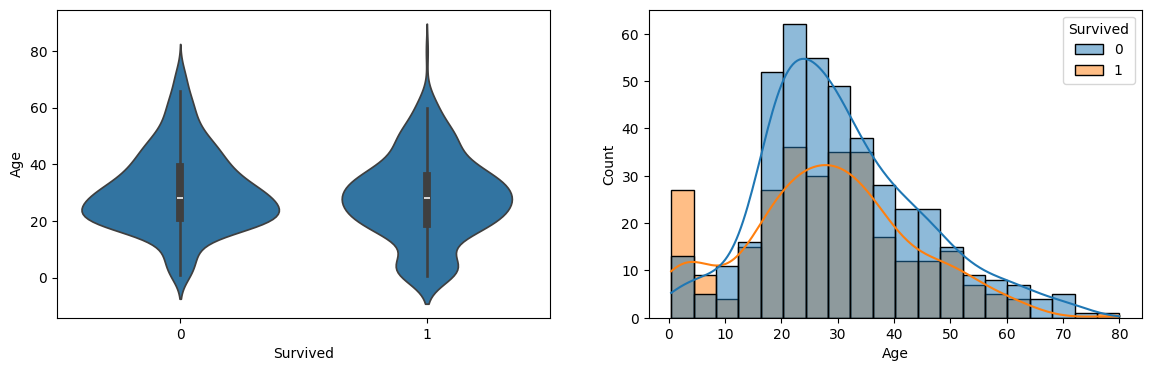

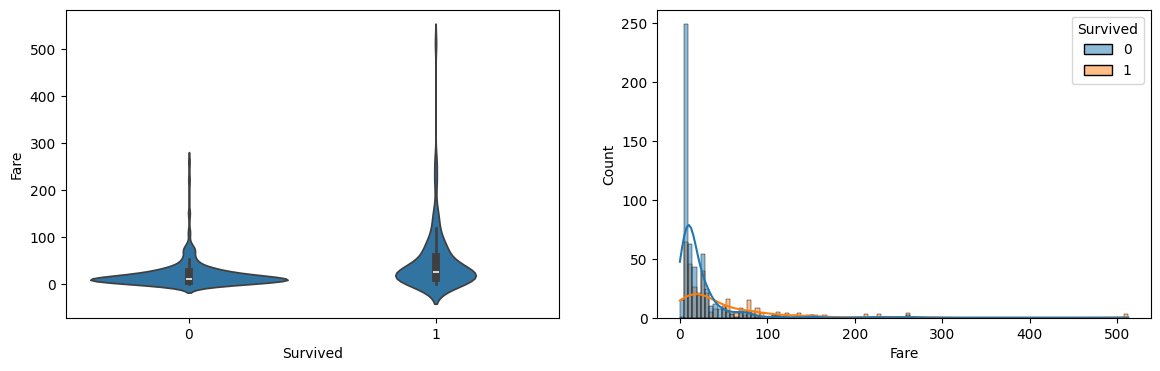

In [33]:
cont_columns = ['Age', 'Fare']

# 리스트로 할당된 칼럼들의 개수만큼 루프 수행
for column in cont_columns:
  # 왼쪽에는 바이올린 플롯, 오른쪽에는 히스토그램을 시각화 nrows는 1, ncols는 2인 서브플롯 생성
  fig, axs = plt.subplots(nrows=1, ncols = 2, figsize=(14, 4))
  # 왼쪽 Axes 객체에는 Survived 값 0, 1별 개별 칼럼의 바이올린 플롯 시각화
  sns.violinplot(x='Survived', y=column, data = titanic_df, ax=axs[0])
  # 오른쪽 Axes 객체에는 Survived 값에 따른 개별 칼럼의 히스토그램 시각화
  sns.histplot(x=column, data = titanic_df, hue = 'Survived', kde = True, ax = axs[1])

**산점도, 스캐터 플롯(Scatter Flot)**

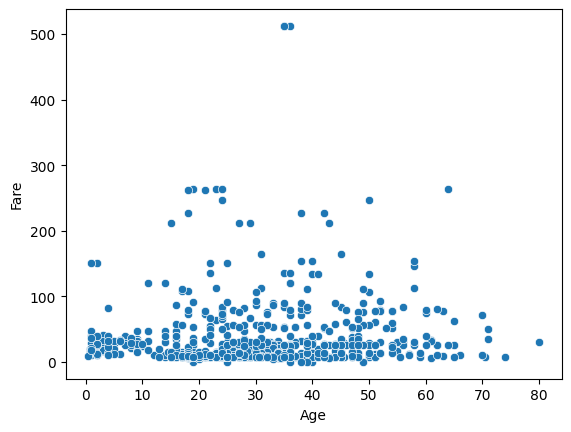

In [34]:
# X축값을 Age, Y축값으로 Fare 설정
sns.scatterplot(x='Age', y='Fare', data = titanic_df)
plt.show()

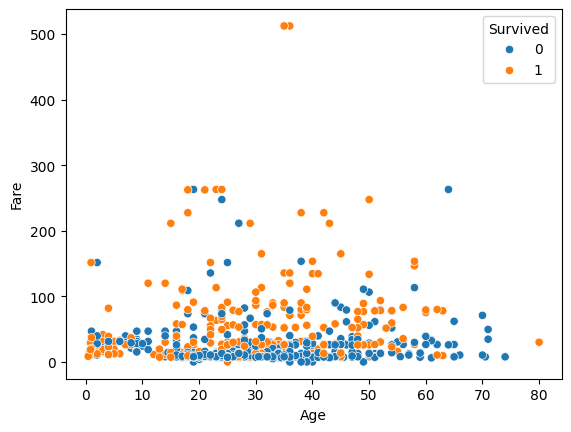

In [36]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data = titanic_df)
plt.show()

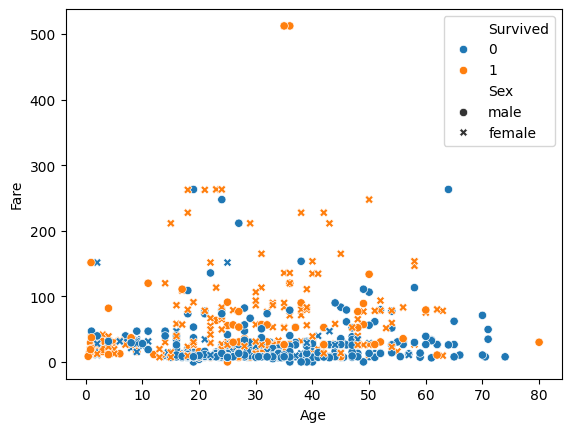

In [37]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', style = 'Sex', data = titanic_df)
plt.show()

상관 히트맵(Correlation Heatmap)
* 다수의 속성들 간의 상관계수를 히트맵 형태로 나타낼 수 있음
* 다수의 칼럼들 간의 상관계수를 온도를 연상시키는 여러 가지 색상으로 표현하여 직관적으로 칼럼들 간의 상관도를 이해할 수 있게 해줌
* heatmap()을 통해서 시각화됨

In [39]:
corr_df = titanic_df.corr(numeric_only = True)
corr_df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


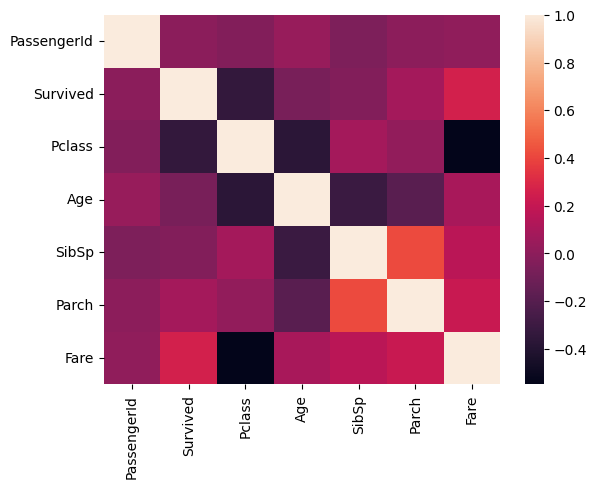

In [40]:
# 상관계수를 DataFrame으로 구하고 이를 heatmap()의 인자로 입력
corr = titanic_df.corr(numeric_only = True)
sns.heatmap(corr)
plt.show()

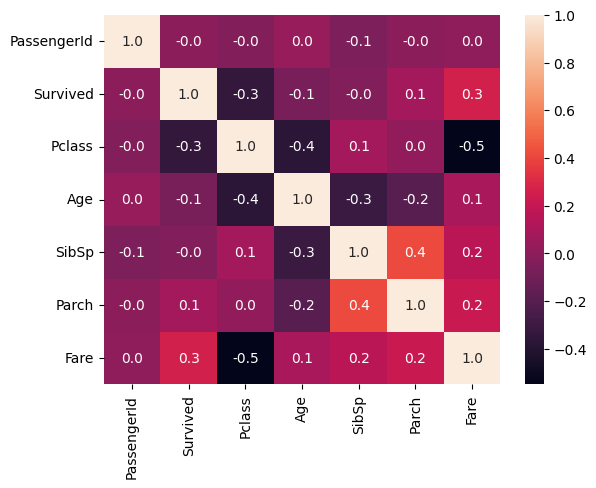

In [42]:
sns.heatmap(corr, annot = True, fmt='.1f', cbar = True)
plt.show()